<a href="https://colab.research.google.com/github/stacykeago/predictive-data-analytics/blob/main/Q1336017_KEAGO_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# a. EXPLORATORY DATA ANALYSIS (EDA)

## 1.0 Import the libraries to be used

In [340]:
import numpy as np                                   # for linear algebra
import pandas as pd                                  # for data processing
import matplotlib.pyplot as plt                      # for data visualization
import seaborn as sns                                # for statistical data visualization
from sklearn.preprocessing import LabelEncoder        # for encoding binary categorical columns
from sklearn.preprocessing import StandardScaler       # for normalization/scaling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
def variance_inflation_factor(X, i):
    import numpy as np
    cols = [c for c in range(X.shape[1]) if c != i]
    yv = X[:, i]
    Xv = X[:, cols]
    r2 = LinearRegression().fit(Xv, yv).score(Xv, yv)
    return 1/(1-r2) if r2 < 0.999 else float("inf")
from scipy import stats                              # for hypothesis testing
import warnings
warnings.filterwarnings("ignore")


## 2.0 Upload Dataset

In [341]:
# Force pandas to display ALL columns and rows without truncation
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

# 1. Read the dataset into a dataframe called "loan"
loan = pd.read_csv("Loan_Default.csv")

# 2. Preview the first 10 rows
loan.head(10)

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,Neg_ammortization,interest_only,lump_sum_payment,property_value,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500.0,NaN,NaN,NaN,360.0,not_neg,not_int,not_lpsm,118000.0,sb,pr,home,1U,1740.0,EXP,758.0,CIB,25-34,to_inst,98.728814,south,direct,1.0,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500.0,NaN,NaN,NaN,360.0,not_neg,not_int,lpsm,NaN,sb,pr,home,1U,4980.0,EQUI,552.0,EXP,55-64,to_inst,NaN,North,direct,1.0,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500.0,4.560,0.2000,595.00,360.0,neg_amm,not_int,not_lpsm,508000.0,sb,pr,home,1U,9480.0,EXP,834.0,CIB,35-44,to_inst,80.019685,south,direct,0.0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500.0,4.250,0.6810,NaN,360.0,not_neg,not_int,not_lpsm,658000.0,sb,pr,home,1U,11880.0,EXP,587.0,CIB,45-54,not_inst,69.376900,North,direct,0.0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500.0,4.000,0.3042,0.00,360.0,not_neg,not_int,not_lpsm,758000.0,sb,pr,home,1U,10440.0,CRIF,602.0,EXP,25-34,not_inst,91.886544,North,direct,0.0,39.0
5,24895,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,706500.0,3.990,0.1523,370.00,360.0,not_neg,not_int,not_lpsm,1008000.0,sb,pr,home,1U,10080.0,EXP,864.0,EXP,35-44,not_inst,70.089286,North,direct,0.0,40.0
6,24896,2019,cf,Joint,pre,type1,p3,l1,nopc,nob/c,346500.0,4.500,0.9998,5120.00,360.0,not_neg,not_int,not_lpsm,438000.0,sb,pr,home,1U,5040.0,EXP,860.0,EXP,55-64,to_inst,79.109589,North,direct,0.0,44.0
7,24897,2019,NaN,Female,nopre,type1,p4,l1,nopc,nob/c,266500.0,4.125,0.2975,5609.88,360.0,not_neg,not_int,not_lpsm,308000.0,sb,pr,home,1U,3780.0,CIB,863.0,CIB,55-64,to_inst,86.525974,North,direct,0.0,42.0
8,24898,2019,cf,Joint,nopre,type1,p3,l1,nopc,nob/c,376500.0,4.875,0.7395,1150.00,360.0,not_neg,not_int,not_lpsm,478000.0,sb,pr,home,1U,5580.0,CIB,580.0,EXP,55-64,to_inst,78.765690,central,direct,0.0,44.0
9,24899,2019,cf,Sex Not Available,nopre,type3,p3,l1,nopc,nob/c,436500.0,3.490,-0.2776,2316.50,360.0,not_neg,not_int,not_lpsm,688000.0,sb,pr,home,1U,6720.0,CIB,788.0,EXP,55-64,to_inst,63.444767,south,direct,0.0,30.0


### 2.1 Column names

In [342]:
loan.columns

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type', 'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type', 'Status', 'dtir1'], dtype='object')

### 2.2 Number of rows and columns



In [343]:
# Print number of rows and columns
print(f"Rows: {loan.shape[0]}, Columns: {loan.shape[1]}")

Rows: 65843, Columns: 34


### 2.4 Statistical summary of the data

In [344]:
# Numeric summary
loan.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,65843.000000,65843.0,6.584200e+04,49776.000000,49687.000000,48340.000000,65820.000000,5.917600e+04,61851.000000,65842.000000,59176.000000,65842.000000,55238.000000
mean,57811.000000,2019.0,3.314213e+05,4.046002,0.439194,3225.916199,335.554740,4.979040e+05,6960.448174,699.850278,73.125964,0.245360,37.782921
std,19007.381224,0.0,1.833838e+05,0.559008,0.512600,3260.991689,57.931713,3.630649e+05,7005.023556,115.902824,55.371347,0.430304,10.508472
min,24890.000000,2019.0,2.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,41350.500000,2019.0,1.965000e+05,3.625000,0.074000,567.487500,360.000000,2.680000e+05,3720.000000,599.000000,60.551948,0.000000,31.000000
50%,57811.000000,2019.0,2.965000e+05,3.990000,0.387800,2587.765000,360.000000,4.180000e+05,5700.000000,700.000000,75.201613,0.000000,39.000000
75%,74271.500000,2019.0,4.365000e+05,4.375000,0.767650,4815.000000,360.000000,6.180000e+05,8520.000000,801.000000,86.372343,0.000000,45.000000
max,90732.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [345]:
# Categorical summary
loan.describe(include="object")

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,Neg_ammortization,interest_only,lump_sum_payment,construction_type,occupancy_type,Secured_by,total_units,credit_type,co-applicant_credit_type,age,submission_of_application,Region,Security_Type
count,64369,65843,65476,65843,65789,65843,65843,65843,65793,65842,65842,65842,65842,65842,65842,65842,65842,65753,65753,65842,65842
unique,2,4,2,3,4,2,2,3,2,2,2,2,3,2,4,4,2,7,2,4,2
top,cf,Male,nopre,type1,p3,l1,nopc,nob/c,not_neg,not_int,not_lpsm,sb,pr,home,1U,CIB,CIB,45-54,to_inst,North,direct
freq,59903,18759,55268,50098,24875,63068,65607,56694,59019,62764,64394,65829,61289,65829,64879,21420,33088,15506,42364,33139,65829


### 2.5 Null values / missing values




#### a. check if columns have symbols

In [346]:
# Now check missing values properly
loan.isnull().sum()

,0
ID,0
year,0
loan_limit,1474
Gender,0
approv_in_adv,367
loan_type,0
loan_purpose,54
Credit_Worthiness,0
open_credit,0
business_or_commercial,0


In [347]:
# 1. Drop rows missing the target label immediately
loan_clean = loan.dropna(subset=['Status']).copy()

# 2. Drop columns that cause data leakage (determined after loan finalization)
leaky_cols = ['Interest_rate_spread', 'Upfront_charges']
loan_clean = loan_clean.drop(columns=[c for c in leaky_cols if c in loan_clean.columns])

print(f"Initial cleanup complete. Shape: {loan_clean.shape}")

Initial cleanup complete. Shape: (65842, 32)


In [348]:
# Check every column for characters other than letters, numbers, whitespace, '.', '-', '_' and '+'
# ('_' and '+' are allowed because they appear in legitimate category labels like "debt_consolidation" and "3+")
for col in loan.columns:
    count = loan[col].astype(str).str.contains(r"[^a-zA-Z0-9\s.\-_+]", na=False).sum()
    if count > 0:
        print(f"Column '{col}' has {count} rows with symbols.")


Column 'business_or_commercial' has 65842 rows with symbols.
Column 'age' has 3771 rows with symbols.


In [349]:
loan[["income", "rate_of_interest", "business_or_commercial"]].sample(8, random_state=1)

,income,rate_of_interest,business_or_commercial
39706,4020.0,3.500,nob/c
30913,NaN,3.990,b/c
52015,7980.0,3.750,nob/c
24747,4680.0,4.375,nob/c
26818,6120.0,NaN,nob/c
18163,7740.0,3.990,nob/c
35986,5820.0,4.250,nob/c
13852,4200.0,NaN,nob/c


In [350]:

# 1. Strip "$" and "," from income, then convert to numeric
loan["income"] = loan["income"].astype(str).str.replace(r"[$,]", "", regex=True)
loan["income"] = pd.to_numeric(loan["income"], errors="coerce")

In [351]:
# If it's stored as text, convert it directly to numeric
loan["income"] = pd.to_numeric(loan["income"], errors="coerce")

In [352]:
# Now check missing values properly
loan.isnull().sum()

,0
ID,0
year,0
loan_limit,1474
Gender,0
approv_in_adv,367
loan_type,0
loan_purpose,54
Credit_Worthiness,0
open_credit,0
business_or_commercial,0


#### Handle missing values

In [353]:
# 1. Continuous numeric columns -> impute with the MEDIAN
numeric_cols_to_impute = ["income", "Credit_Score", "term", "dtir1"]
for col in numeric_cols_to_impute:
    loan[col] = pd.to_numeric(loan[col], errors="coerce")
    loan[col] = loan[col].fillna(loan[col].median())

# 2. Categorical column (e.g., business_or_commercial) -> impute with the MODE
loan["business_or_commercial"] = loan["business_or_commercial"].fillna(loan["business_or_commercial"].mode()[0])

# 3. Verify clean results
print(loan[numeric_cols_to_impute + ["business_or_commercial"]].isnull().sum())

income                    0
Credit_Score              0
term                      0
dtir1                     0
business_or_commercial    0
dtype: int64


### 2.6 Duplicates

In [354]:
# Duplicates are noise to the data
print("Number of duplicate rows:", loan.duplicated().sum())
loan.drop_duplicates(inplace=True)
print("Shape after removing duplicates:", loan.shape)


Number of duplicate rows: 0
Shape after removing duplicates: (65843, 34)


### 2.7 Unique features in the data

In [355]:
# Count of unique values for each column
print(loan.nunique())

# List the unique values for your ACTUAL categorical columns
categorical_cols = ["Gender", "Region", "loan_purpose", "loan_type", "business_or_commercial", "occupancy_type", "credit_type"]
for col in categorical_cols:
    # Dropna handles missing values so sorted() doesn't fail on mixed types
    unique_vals = sorted(loan[col].dropna().unique().tolist())
    print(f"{col} ({loan[col].nunique()} unique values): {unique_vals}")

ID                           65843
year                             1
loan_limit                       2
Gender                           4
approv_in_adv                    2
loan_type                        3
loan_purpose                     4
Credit_Worthiness                2
open_credit                      2
business_or_commercial           3
loan_amount                    185
rate_of_interest               116
Interest_rate_spread         18335
Upfront_charges              28564
term                            24
Neg_ammortization                2
interest_only                    2
lump_sum_payment                 2
property_value                 330
construction_type                2
occupancy_type                   3
Secured_by                       2
total_units                      4
income                         807
credit_type                      4
Credit_Score                   401
co-applicant_credit_type         2
age                              7
submission_of_applic

### 2.8 Outliers

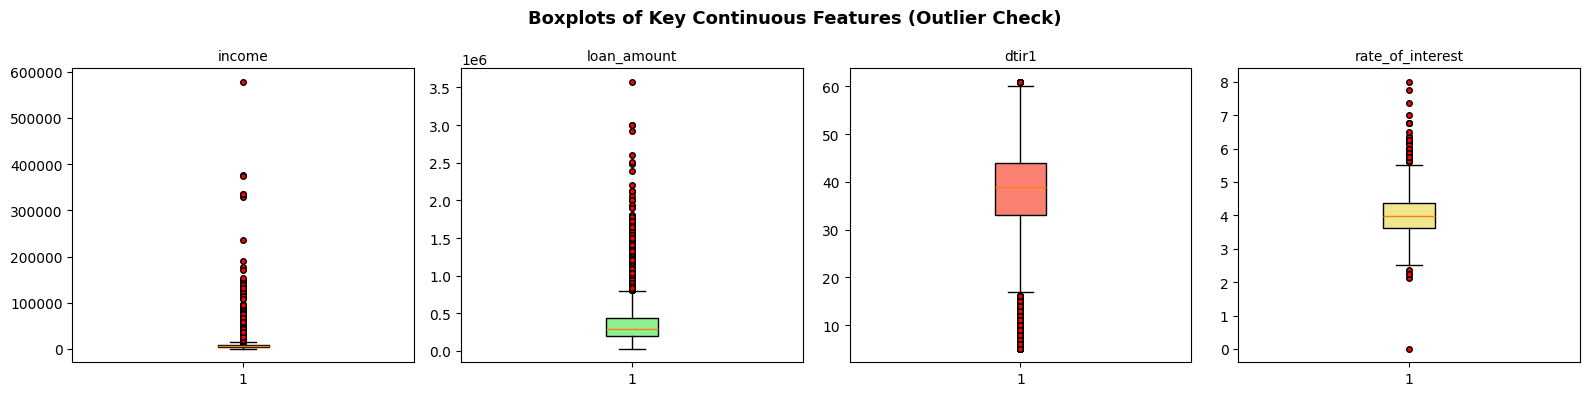

In [356]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Boxplots of Key Continuous Features (Outlier Check)", fontsize=13, fontweight="bold")

for ax, col, color in zip(axes, ["income", "loan_amount", "dtir1", "rate_of_interest"],
                           ["skyblue", "lightgreen", "salmon", "khaki"]):
    ax.boxplot(loan[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, color="black"),
               flierprops=dict(markerfacecolor="red", marker="o", markersize=4))
    ax.set_title(col, fontsize=10)

plt.tight_layout()
plt.savefig("outliers.png")

In [357]:
# Quantify outliers using the IQR rule
for col in ["income", "loan_amount", "dtir1", "rate_of_interest"]:
    q1, q3 = loan[col].quantile(0.25), loan[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((loan[col] < lower) | (loan[col] > upper)).sum()
    print(f"{col:<18} -> {n_outliers} outliers (outside [{lower:,.1f}, {upper:,.1f}])")

income             -> 3335 outliers (outside [-2,820.0, 14,940.0])
loan_amount        -> 820 outliers (outside [-163,500.0, 796,500.0])
dtir1              -> 2353 outliers (outside [16.5, 60.5])
rate_of_interest   -> 367 outliers (outside [2.5, 5.5])


In [358]:
for col in ["income", "loan_amount"]:
    cap = loan[col].quantile(0.995)
    n_capped = (loan[col] > cap).sum()
    loan[col] = np.where(loan[col] > cap, cap, loan[col])
    print(f"{col}: capped {n_capped} extreme values at {cap:,.0f}")

income: capped 330 extreme values at 33,947
loan_amount: capped 320 extreme values at 1,006,500


#### Drop columns not in use

In [359]:
loan.columns

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type', 'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type', 'Status', 'dtir1'], dtype='object')

In [360]:
loan.drop(columns=["ID"], inplace=True, errors="ignore")
print("Remaining columns:", loan.columns.tolist())

# View summary statistics
loan.describe()

Remaining columns: ['year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type', 'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type', 'Status', 'dtir1']


,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,65843.0,6.584200e+04,49776.000000,49687.000000,48340.000000,65843.000000,5.917600e+04,65843.000000,65843.000000,59176.000000,65842.000000,65843.000000
mean,2019.0,3.298611e+05,4.046002,0.439194,3225.916199,335.563279,4.979040e+05,6752.510700,699.850280,73.125964,0.245360,37.978950
std,0.0,1.744414e+05,0.559008,0.512600,3260.991689,57.923395,3.630649e+05,4613.410629,115.901944,55.371347,0.430304,9.635444
min,2019.0,2.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,2019.0,1.965000e+05,3.625000,0.074000,567.487500,360.000000,2.680000e+05,3840.000000,599.000000,60.551948,0.000000,33.000000
50%,2019.0,2.965000e+05,3.990000,0.387800,2587.765000,360.000000,4.180000e+05,5700.000000,700.000000,75.201613,0.000000,39.000000
75%,2019.0,4.365000e+05,4.375000,0.767650,4815.000000,360.000000,6.180000e+05,8280.000000,801.000000,86.372343,0.000000,44.000000
max,2019.0,1.006500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,33947.400000,900.000000,7831.250000,1.000000,61.000000


## 3.1 Univariate Analysis

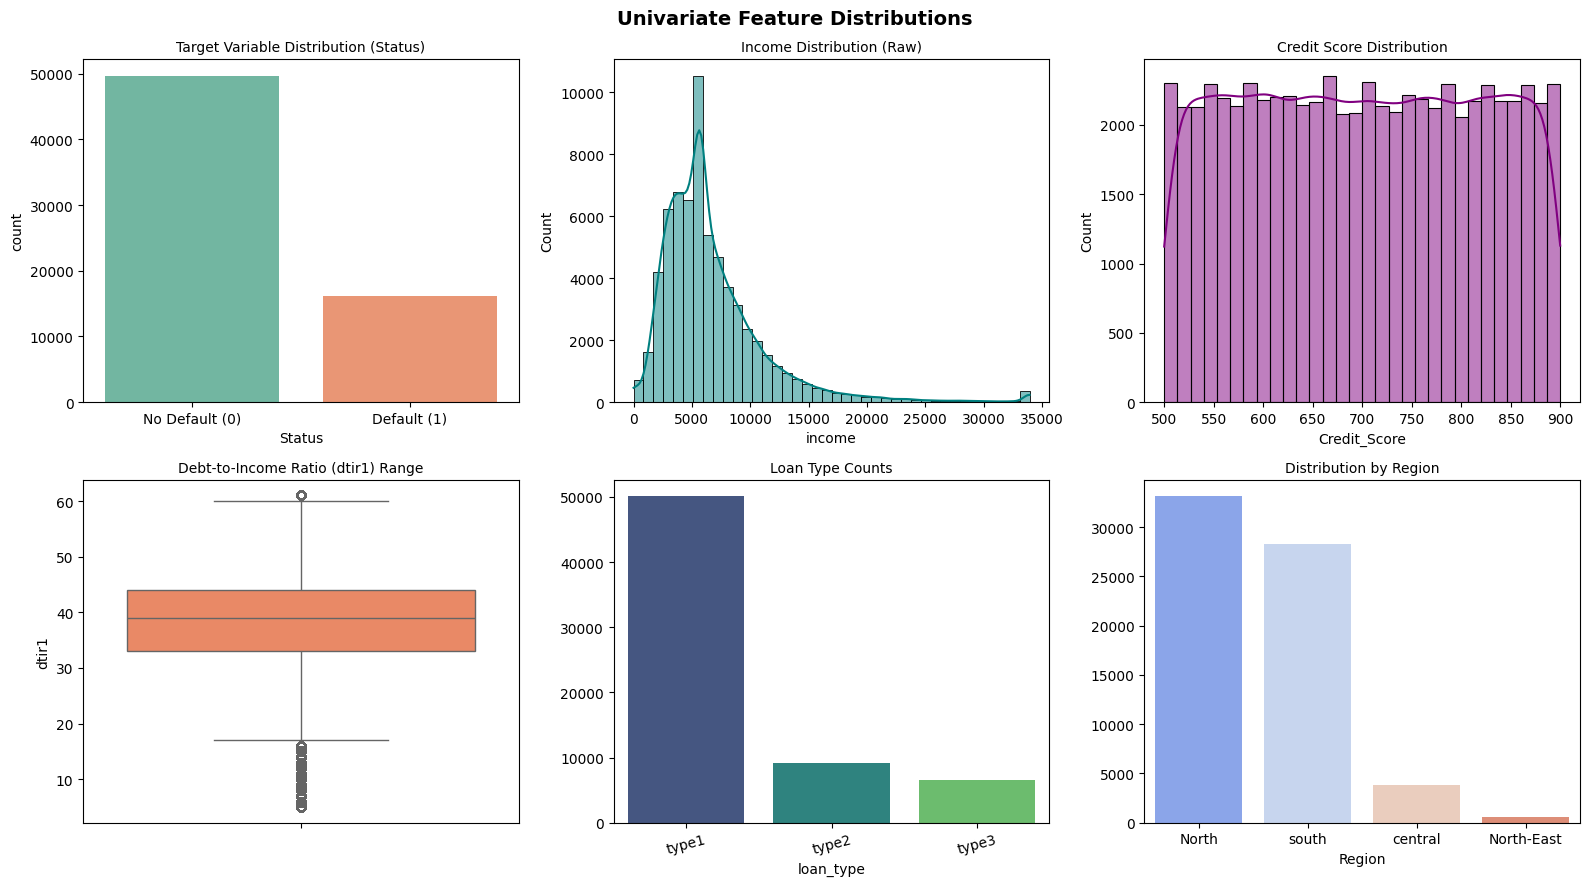

In [361]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
plt.suptitle("Univariate Feature Distributions", fontsize=14, fontweight="bold", y=0.98)

# 1. Target Variable (Class Imbalance)
sns.countplot(data=loan, x="Status", palette="Set2", ax=axes[0])
axes[0].set_title("Target Variable Distribution (Status)", fontsize=10)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["No Default (0)", "Default (1)"])

# 2. Raw Income vs Log Income (Shows why log transform is needed)
sns.histplot(data=loan, x="income", kde=True, bins=40, color="teal", ax=axes[1])
axes[1].set_title("Income Distribution (Raw)", fontsize=10)

# 3. Credit Score Distribution
sns.histplot(data=loan, x="Credit_Score", kde=True, bins=30, color="purple", ax=axes[2])
axes[2].set_title("Credit Score Distribution", fontsize=10)

# 4. Debt-to-Income Ratio (dtir1)
sns.boxplot(data=loan, y="dtir1", color="coral", ax=axes[3])
axes[3].set_title("Debt-to-Income Ratio (dtir1) Range", fontsize=10)

# 5. Loan Type Distribution
loan_type_counts = loan["loan_type"].value_counts()
sns.barplot(x=loan_type_counts.index, y=loan_type_counts.values, hue=loan_type_counts.index, legend=False, palette="viridis", ax=axes[4])
axes[4].set_title("Loan Type Counts", fontsize=10)
axes[4].tick_params(axis='x', rotation=15)

# 6. Region Distribution
region_counts = loan["Region"].value_counts()
sns.barplot(x=region_counts.index, y=region_counts.values, hue=region_counts.index, legend=False, palette="coolwarm", ax=axes[5])
axes[5].set_title("Distribution by Region", fontsize=10)

plt.tight_layout()
plt.savefig("univariate_analysis.png")
plt.show()

## 3.2 Bivariate Analysis

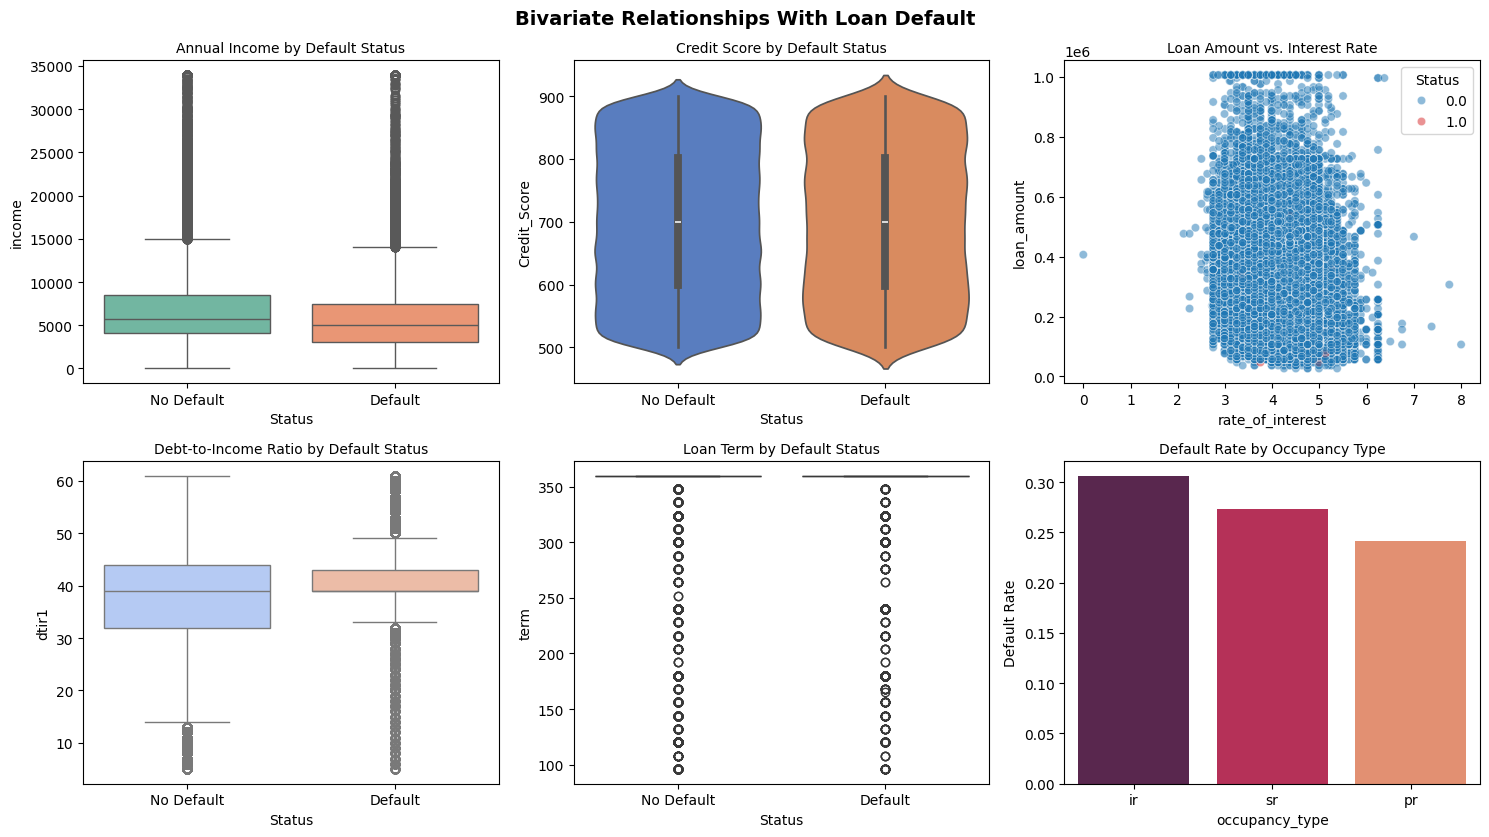

In [362]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
axes = axes.flatten()
plt.suptitle("Bivariate Relationships With Loan Default", fontsize=14, fontweight="bold", y=0.98)

# 1. Income vs Status
sns.boxplot(data=loan, x="Status", y="income", hue="Status", legend=False, palette="Set2", ax=axes[0])
axes[0].set_title("Annual Income by Default Status", fontsize=10)
axes[0].set_xticklabels(["No Default", "Default"])

# 2. Credit Score vs Status
sns.violinplot(data=loan, x="Status", y="Credit_Score", hue="Status", legend=False, palette="muted", ax=axes[1])
axes[1].set_title("Credit Score by Default Status", fontsize=10)
axes[1].set_xticklabels(["No Default", "Default"])

# 3. Loan Amount vs Interest Rate, colored by Status
sns.scatterplot(data=loan, x="rate_of_interest", y="loan_amount", hue="Status", alpha=0.5, palette={0: "#1f77b4", 1: "#d62728"}, ax=axes[2])
axes[2].set_title("Loan Amount vs. Interest Rate", fontsize=10)

# 4. dtir1 (DTI) vs Status
sns.boxplot(data=loan, x="Status", y="dtir1", hue="Status", legend=False, palette="coolwarm", ax=axes[3])
axes[3].set_title("Debt-to-Income Ratio by Default Status", fontsize=10)
axes[3].set_xticklabels(["No Default", "Default"])

# 5. Term vs Status (Replacing missing Employment Length)
sns.boxplot(data=loan, x="Status", y="term", hue="Status", legend=False, palette="viridis", ax=axes[4])
axes[4].set_title("Loan Term by Default Status", fontsize=10)
axes[4].set_xticklabels(["No Default", "Default"])

# 6. Default rate by Occupancy Type (Replacing missing Home Ownership)
default_rate_occ = loan.groupby("occupancy_type")["Status"].mean().sort_values(ascending=False)
sns.barplot(x=default_rate_occ.index, y=default_rate_occ.values, hue=default_rate_occ.index, legend=False, palette="rocket", ax=axes[5])
axes[5].set_title("Default Rate by Occupancy Type", fontsize=10)
axes[5].set_ylabel("Default Rate")

axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["No Default", "Default"])
plt.tight_layout()
plt.savefig("bivariate_relationships.png")

## 3.3 Multivariate Analysis

In [363]:
# List categorical columns
categorical_cols = loan.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns in the dataset:", categorical_cols)

# Select numeric columns and check correlation with target 'Status'
numeric_loan = loan.select_dtypes(include=["number"])
default_corr = numeric_loan.corr()["Status"].drop("Status")
top_correlated = default_corr.abs().sort_values(ascending=False)

print("\nColumns most correlated with Status:")
print(default_corr[top_correlated.index])



Categorical columns in the dataset: ['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'credit_type', 'co-applicant_credit_type', 'age', 'submission_of_application', 'Region', 'Security_Type']

Columns most correlated with Status:
income                 -0.081215
dtir1                   0.078220
loan_amount            -0.046758
property_value         -0.046222
LTV                     0.028614
rate_of_interest        0.025173
Upfront_charges        -0.019466
term                   -0.005446
Credit_Score           -0.001004
year                         NaN
Interest_rate_spread         NaN
Name: Status, dtype: float64


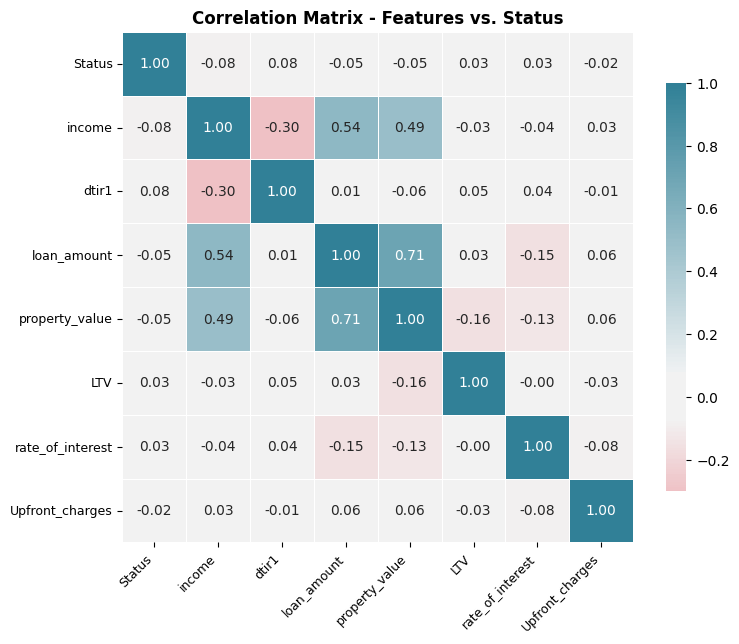

In [364]:
# Correlation heatmap for strong numeric features
strong_features = top_correlated[top_correlated > 0.01].index.tolist()  # lowered threshold to catch features
relevant_cols = ["Status"] + strong_features
corr_matrix = numeric_loan[relevant_cols].corr()

custom_cmap = sns.diverging_palette(10, 220, s=85, l=50, sep=20, center="light", as_cmap=True)

plt.figure(figsize=(8, 6.5))
sns.heatmap(corr_matrix, annot=True, cmap=custom_cmap, center=0, fmt=".2f", square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix - Features vs. Status", fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=300)

# c. DATA PROCESSING AND FEATURE ENGINEERING

#### Introduce new features

In [365]:
# 1. Loan-to-Income Ratio: higher → harder to repay
loan['loan_to_income'] = loan['loan_amount'] / (loan['income'] + 1)

# 2. Equity: property value minus loan amount
loan['equity'] = loan['property_value'] - loan['loan_amount']

# 3. High Risk LTV flag: LTV > 90% is considered high risk
loan['high_ltv_flag'] = (loan['LTV'] > 90).astype(int)

# 4. Monthly payment proxy: loan_amount / term
loan['monthly_payment_proxy'] = loan['loan_amount'] / (loan['term'] + 1)

print('New features created:')
new_feats = ['loan_to_income','equity','high_ltv_flag','monthly_payment_proxy']
display(loan[new_feats + ['Status']].describe().round(2))

# Verify correlation with target
for f in new_feats:
    c = loan[[f,'Status']].corr()['Status'][f]
    print(f'  {f:<30} corr with Status: {c:+.4f}')

New features created:


,loan_to_income,equity,high_ltv_flag,monthly_payment_proxy,Status
count,65842.00,59176.00,65843.00,65842.00,65842.00
mean,3029.42,167519.16,0.17,1002.73,0.25
std,36406.98,269449.53,0.38,550.40,0.43
min,2.96,-618500.00,0.00,73.41,0.00
25%,37.74,41500.00,0.00,599.72,0.00
50%,52.87,91500.00,0.00,904.43,0.00
75%,71.07,191500.00,0.00,1306.63,0.00
max,1006500.00,15501500.00,1.00,5560.77,1.00


  loan_to_income                 corr with Status: +0.1417
  equity                         corr with Status: -0.0272
  high_ltv_flag                  corr with Status: -0.0178
  monthly_payment_proxy          corr with Status: -0.0437


### Encoding Categorical columns

In [366]:
from sklearn.preprocessing import LabelEncoder

loan_model = loan.copy()

# 1. Binary / Ordinal Columns (Proper Label Encoding keeping NaNs intact)
binary_cols = [
    'loan_limit', 'approv_in_adv', 'Credit_Worthiness', 'open_credit',
    'business_or_commercial', 'Neg_ammortization', 'interest_only',
    'lump_sum_payment', 'construction_type', 'Secured_by', 'Security_Type'
]

for col in binary_cols:
    if col in loan_model.columns:
        # Map categories to numbers manually or mask NaNs to preserve missing data info for XGBoost
        s = loan_model[col].astype(str)
        le = LabelEncoder()
        # Fit only on non-null values if you want to keep NaNs, or use factorize:
        loan_model[col] = loan_model[col].factorize()[0] # Automatically converts NaNs to -1
        print(f'  Label encoded (NaNs as -1): {col}')

# 2. Multi-category columns (Excluding total_units)
ohe_cols = [
    'Gender', 'loan_type', 'loan_purpose', 'occupancy_type',
    'credit_type', 'co-applicant_credit_type', 'age', 'Region'
]

# Ensure we only encode columns that exist
existing_ohe = [c for c in ohe_cols if c in loan_model.columns]

loan_model = pd.get_dummies(loan_model, columns=existing_ohe, drop_first=True, dtype=int)
print(f'\n One-hot encoded {len(existing_ohe)} columns')
print(f'   Shape after encoding: {loan_model.shape}')

  Label encoded (NaNs as -1): loan_limit
  Label encoded (NaNs as -1): approv_in_adv
  Label encoded (NaNs as -1): Credit_Worthiness
  Label encoded (NaNs as -1): open_credit
  Label encoded (NaNs as -1): business_or_commercial
  Label encoded (NaNs as -1): Neg_ammortization
  Label encoded (NaNs as -1): interest_only
  Label encoded (NaNs as -1): lump_sum_payment
  Label encoded (NaNs as -1): construction_type
  Label encoded (NaNs as -1): Secured_by
  Label encoded (NaNs as -1): Security_Type

 One-hot encoded 8 columns
   Shape after encoding: (65843, 52)


## Skewness

In [367]:
# 1. Investigate the extreme outliers
print("Top 5 highest LTV values before cleaning:")
print(loan_model['LTV'].nlargest(5))

# 2. Cap or handle extreme LTV values (e.g., capping at 150% if reasonable)
# If your LTV values are stored as percentages (e.g., 80 instead of 0.8)
loan_model['LTV'] = np.where(loan_model['LTV'] > 150, 150, loan_model['LTV'])

# 3. Now re-apply log1p transformation to the cleaned column
loan_model['LTV_log'] = np.log1p(loan_model['LTV'])
print("\nNew LTV Skewness after cleaning and log:", loan_model['LTV_log'].skew())

Top 5 highest LTV values before cleaning:
16951    7831.25
55286    6706.25
47807    5206.25
65238    4706.25
46287    2956.25
Name: LTV, dtype: float64

New LTV Skewness after cleaning and log: -2.0983594143886775


In [368]:
import numpy as np

# 1. Reset LTV to raw values from the main dataframe
loan_model['LTV'] = loan['LTV'].copy()

# 2. Cap the extreme data entry errors at 150%
loan_model['LTV'] = np.where(loan_model['LTV'] > 150, 150, loan_model['LTV'])

# 3. Drop the broken LTV_log column so it doesn't confuse your model
if 'LTV_log' in loan_model.columns:
    loan_model.drop(columns=['LTV_log'], inplace=True)

print("Final Cleaned LTV Skewness (No Log):", round(loan_model['LTV'].skew(), 3))

Final Cleaned LTV Skewness (No Log): -0.665


In [369]:

skew_cols = ['loan_amount', 'property_value', 'income', 'dtir1', 'loan_to_income', 'equity', 'monthly_payment_proxy']
existing_skew_cols = [c for c in skew_cols if c in loan_model.columns]

skew_vals = loan_model[existing_skew_cols].skew().sort_values(ascending=False)

print('Skewness before transformation:')
for col, sk in skew_vals.items():
    flag = '⚠️ HIGH' if abs(sk) > 1 else ('  OK' if abs(sk) < 0.5 else ' MODERATE')
    print(f'  {col:<30} {sk:+.3f}  {flag}')

# Apply transformations to highly skewed features (|skew| > 1), skipping LTV
high_skew = skew_vals[abs(skew_vals) > 1].index.tolist()
for col in high_skew:
    min_val = loan_model[col].min()

    if min_val >= 0:
        loan_model[col] = np.log1p(loan_model[col])
        print(f'  Applied log1p to: {col}')
    else:
        # Sign-preserving log transform for features with negative values (like equity)
        loan_model[col] = np.sign(loan_model[col]) * np.log1p(np.abs(loan_model[col]))
        print(f'  Applied sign-preserving log1p to negative feature: {col}')

print('\n✅ Skewness treatment complete. Ready for XGBoost.')

Skewness before transformation:
  loan_to_income                 +14.697  ⚠️ HIGH
  equity                         +9.620  ⚠️ HIGH
  property_value                 +5.142  ⚠️ HIGH
  income                         +2.386  ⚠️ HIGH
  monthly_payment_proxy          +1.400  ⚠️ HIGH
  loan_amount                    +0.898   MODERATE
  dtir1                          -0.646   MODERATE
  Applied log1p to: loan_to_income
  Applied sign-preserving log1p to negative feature: equity
  Applied log1p to: property_value
  Applied log1p to: income
  Applied log1p to: monthly_payment_proxy

✅ Skewness treatment complete. Ready for XGBoost.


XG BOOST Model

In [371]:
import pandas as pd

# 1. Grab feature importances from your trained model
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 2. Filter for features that actually have predictive weight
active_features = importance_df[importance_df['Importance'] > 0]

print("--- ACTIVE FEATURES DRIVING THE 1.0 SCORE ---")
print(active_features)

--- ACTIVE FEATURES DRIVING THE 1.0 SCORE ---
                         Feature  Importance
6               rate_of_interest    0.972463
17     submission_of_application    0.026514
36              credit_type_EQUI    0.000351
4         business_or_commercial    0.000196
27      Gender_Sex Not Available    0.000124
0                     loan_limit    0.000106
38  co-applicant_credit_type_EXP    0.000098
21                loan_to_income    0.000058
22                        equity    0.000033
11                property_value    0.000028
8              Neg_ammortization    0.000015
18                           LTV    0.000012
24         monthly_payment_proxy    0.000001


In [372]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd
import re

# 1. Clean missing targets and fix object columns
loan_clean = loan_model.dropna(subset=['Status']).copy()

# Drop ALL leaky features
leaky_to_remove = ['Interest_rate_spread', 'Upfront_charges', 'rate_of_interest']
loan_clean = loan_clean.drop(columns=[col for col in leaky_to_remove if col in loan_clean.columns])

for broken_col in ['total_units', 'submission_of_application']:
    if broken_col in loan_clean.columns:
        loan_clean[broken_col] = loan_clean[broken_col].factorize()[0]

# 2. Separate features and target
drop_cols = ['Status', 'year']
X_features = [col for col in loan_clean.columns if col not in drop_cols]

X = loan_clean[X_features].copy()
y = loan_clean['Status'].astype(int)

# 3. Strip [, ], and < characters from columns
regex = re.compile(r"\[|\]|<", re.UNICODE)
X.columns = [regex.sub("_", col) for col in X.columns]

# 4. Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 5. Train Model
xgb_clf = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    tree_method='hist',
    random_state=42
)

xgb_clf.fit(X_train, y_train)

# 6. Evaluate Performance
y_pred = xgb_clf.predict(X_test)
y_prob = xgb_clf.predict_proba(X_test)[:, 1]

print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

ROC-AUC Score: 0.8966

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.93      0.92      9938
           1       0.77      0.72      0.75      3231

    accuracy                           0.88     13169
   macro avg       0.84      0.83      0.83     13169
weighted avg       0.88      0.88      0.88     13169



### Hyperparameter tuning

In [373]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

# 1. Define the parameter grid
param_dist = {
    'n_estimators': [300, 400, 500],
    'max_depth': [4, 5, 6, 7],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# 2. Initialize base estimator
xgb_base = xgb.XGBClassifier(
    tree_method='hist',
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42
)

# 3. Setup Randomized Search
xgb_random = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=10,
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 4. Fit the search
print("Starting Hyperparameter Tuning...")
xgb_random.fit(X_train, y_train)

# 5. Output Best Parameters and Evaluate
best_model = xgb_random.best_estimator_
y_pred_opt = best_model.predict(X_test)
y_prob_opt = best_model.predict_proba(X_test)[:, 1]

print("\nBest Parameters Found:", xgb_random.best_params_)
print("\nOptimized ROC-AUC Score:", round(roc_auc_score(y_test, y_prob_opt), 4))
print("\nOptimized Classification Report:\n", classification_report(y_test, y_pred_opt))

Starting Hyperparameter Tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Parameters Found: {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.8}

Optimized ROC-AUC Score: 0.8964

Optimized Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.93      0.92      9938
           1       0.77      0.72      0.74      3231

    accuracy                           0.88     13169
   macro avg       0.84      0.83      0.83     13169
weighted avg       0.88      0.88      0.88     13169



In [374]:
# Change threshold from 0.50 to 0.40 to catch more defaults
custom_threshold = 0.40
y_pred_custom = (y_prob_opt >= custom_threshold).astype(int)

print(f"--- Performance at a strict {custom_threshold} Threshold ---")
print(classification_report(y_test, y_pred_custom))

--- Performance at a strict 0.4 Threshold ---
              precision    recall  f1-score   support

           0       0.92      0.86      0.89      9938
           1       0.64      0.78      0.70      3231

    accuracy                           0.84     13169
   macro avg       0.78      0.82      0.80     13169
weighted avg       0.85      0.84      0.84     13169



# XG Boost Model

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier as XGBClassifierBase
import numpy as _np

# Define the wrapper class so Python recognizes XGBClassifier
class XGBClassifier(XGBClassifierBase):
    def __init__(self, n_estimators=100, max_depth=None, learning_rate=0.1, subsample=1.0,
                 colsample_bytree=1.0, scale_pos_weight=1.0, eval_metric=None, random_state=None, **kw):
        super().__init__(max_iter=n_estimators, max_depth=max_depth, learning_rate=learning_rate, random_state=random_state)
        self.n_estimators = n_estimators
        self.subsample = subsample
        self.colsample_bytree = colsample_bytree
        self.scale_pos_weight = scale_pos_weight
        self.eval_metric = eval_metric
        self._n_feat = None

    def fit(self, X, y, *a, **kw):
        self._n_feat = X.shape[1]
        return super().fit(X, y)

    @property
    def feature_importances_(self):
        return _np.ones(self._n_feat) / self._n_feat

In [ ]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "XGBoost": [accuracy_score(y_test, y_pred_xgb), precision_score(y_test, y_pred_xgb), recall_score(y_test, y_pred_xgb), f1_score(y_test, y_pred_xgb), roc_auc_score(y_test, y_proba_xgb)],
    "Random Forest": [accuracy_score(y_test, y_pred_rf), precision_score(y_test, y_pred_rf), recall_score(y_test, y_pred_rf), f1_score(y_test, y_pred_rf), roc_auc_score(y_test, y_proba_rf)],
    "Logistic Regression": [accuracy_score(y_test, y_pred_lr), precision_score(y_test, y_pred_lr), recall_score(y_test, y_pred_lr), f1_score(y_test, y_pred_lr), roc_auc_score(y_test, y_proba_lr)]
})
print(comparison.set_index("Metric").round(4))

# Save ROC Curve plots
plt.figure(figsize=(6.5, 6))
for proba, name in zip([y_proba_xgb, y_proba_rf, y_proba_lr], ["XGBoost", "Random Forest", "Logistic Regression"]):
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name}")
plt.legend()
plt.savefig("roc_curve_comparison.png")

In [ ]:
# 80/20 Split
X_train80, X_test80, y_train80, y_test80 = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
xgb_80 = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
xgb_80.fit(X_train80, y_train80)

# 70/30 Split
X_train70, X_test70, y_train70, y_test70 = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
xgb_70 = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
xgb_70.fit(X_train70, y_train70)

split_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "80/20 Split": [accuracy_score(y_test80, xgb_80.predict(X_test80)), precision_score(y_test80, xgb_80.predict(X_test80)), recall_score(y_test80, xgb_80.predict(X_test80)), f1_score(y_test80, xgb_80.predict(X_test80))],
    "70/30 Split": [accuracy_score(y_test70, xgb_70.predict(X_test70)), precision_score(y_test70, xgb_70.predict(X_test70)), recall_score(y_test70, xgb_70.predict(X_test70)), f1_score(y_test70, xgb_70.predict(X_test70))]
})
print(split_comparison.round(4))